In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Example binary dataset
X = np.array([
    [2,3],
    [1,2],
    [3,4],
    [5,6],
    [6,7],
    [7,8]
])

y = np.array([0,0,0,1,1,1])

# reshape y to column vector
y = y.reshape(-1,1)

# number of samples, features
n, m = X.shape


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [4]:
w = np.zeros((m,1))
b = 0

alpha = 0.01     # learning rate
T = 1000         # iterations


In [5]:
loss_history = []

for t in range(T):

    # a) Linear combination
    Z = np.dot(X, w) + b
    
    # b) Sigmoid prediction
    y_hat = sigmoid(Z)
    
    # c) Error
    error = y_hat - y
    
    # Logistic loss (for monitoring)
    loss = -(1/n)*np.sum(y*np.log(y_hat+1e-9) + (1-y)*np.log(1-y_hat+1e-9))
    loss_history.append(loss)
    
    # d) Gradient w.r.t weights
    dw = (1/n) * np.dot(X.T, error)
    
    # e) Gradient w.r.t bias
    db = (1/n) * np.sum(error)
    
    # f) Update weights
    w = w - alpha * dw
    
    # g) Update bias
    b = b - alpha * db


In [6]:
def predict(X, w, b):
    probs = sigmoid(np.dot(X, w) + b)
    return (probs >= 0.5).astype(int)


In [7]:
predictions = predict(X, w, b)

print("Predictions:\n", predictions)
print("Actual:\n", y)


Predictions:
 [[0]
 [0]
 [0]
 [1]
 [1]
 [1]]
Actual:
 [[0]
 [0]
 [0]
 [1]
 [1]
 [1]]


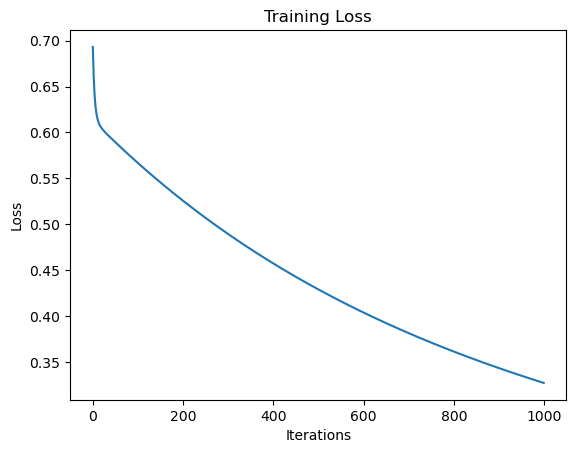

In [8]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()
